# M8 network inference — POV-Ray illustration

Thin notebook: schematic of the **Encode CNN** (16→32→64, 128×128), three readouts (average pooling / Fourier pooling / flatten), MLP head, and 3D localization panel.

Feature-volume colours use the trained Fourier xyz checkpoint when `torch` and `checkpoints/m8/m08_train_val_test_xyz.pt` are present; otherwise FALLBACK maps (warned).

Inspection cells below the export use the **same** ``bundle`` as the POV figure (CNN maps, Fourier term×activation, pooled embedding, head/MLP strips, xyz).

Install from the repo root (no editable install): `pip install ".[dl]" -c requirements.txt`

In [ ]:
from gummybear.paths import display_path, repo_relative_path
from gummybear_illustration import export_m8_network_scene
from gummybear_illustration.load_sample import load_m8_physical_setup
from gummybear_illustration.network_activation_preview import show_bundle_inspections
from gummybear_illustration.network_activations import collect_m8_network_activations
from gummybear_illustration.network_captions import (
    COLOR_FOURIER,
    COLOR_GAP,
    COLOR_TARGET,
    overlay_network_captions,
)
from gummybear_illustration.paths import repo_root

ROOT = repo_root()

SAMPLE_INDEX = 0
CAMERA_ANGLE_DEG = 180
OUTPUT_POV = ROOT / "outputs" / "pov" / "m8_network_scene.pov"
RENDER = True
CHECKPOINT_PATH = None  # None = checkpoints/m8/m08_train_val_test_xyz.pt

ILLUSTRATION_YAW_DEG = 80.0
ILLUSTRATION_FOV_DEG = 60.0
ILLUSTRATION_DISTANCE_SCALE = 1.22
ILLUSTRATION_ZSCORE_CLIP = 0.5
# CNN / 2×2 panes: "zscore" = per-slice (x-mean)/std then turbo in ±CLIP; "minmax" = per-slice min/max.
SLICE_COLORMAP = "minmax"
SLICE_COLORMAP_CLIP = 2.0
# World-up plate yaw from camera-facing (0 = face the camera, 90 = edge-on / pipeline).
FOURIER_PANE_YAW_DEG = 220.0

# Joint world offset of the Fourier 2×2 pane and its embedding slab.
# Same axes as INPUT_STACK_CENTER: larger y = further left in the frame.
FOURIER_GROUP_OFFSET = (0.0, -1.0, 0.0)

# Shift CNN volumes + Fourier pane + Fourier embedding toward the camera (world units).
CNN_FOURIER_FRONT = 30.0

# World centre of the input z-score plate (world-up). Larger y = further left in the frame.
# z is raised with the 1.5× face so the plate still sits above the floor.
INPUT_STACK_CENTER = (50.0, 63.0, 16.0)
INPUT_STACK_SCALE = 1.5

# Fourier embedding slab vs the 2×2 pane (plate-local):
#   front: extra gap in front of the pane (beyond pane half-thickness + slab radius)
#   right: screen-right shift
#   up: lift from the spatial bottom of the pane (0 = sitting on the bottom edge)
FOURIER_EMBED_OFFSET = (5, -20.6, 1.0)
# Uniform scale of slab length and thickness (1 = pane-width bar).
FOURIER_EMBED_SCALE = 1.25

# GAP pooling slab (behind the CNN): yaw about world z from the pipeline axis; 1 = default size.
GAP_EMBED_YAW_DEG = 40.0
GAP_EMBED_SCALE = 1.25
# Along the pooling CNN line after the −90° rotate; larger = further right in the frame.
GAP_EMBED_SHIFT = 20.0

# PNG overlay only (not POV). Fractions of width/height; PIL y from the top.
# Set a key to None to hide that caption. Re-run the caption cell after edits.
CAPTION_POSITIONS = {
    "input": (0.07, 0.62),
    "cnn": (0.23, 0.80),
    "layer1": (0.12, 0.725),
    "layer2": (0.22, 0.74),
    "layer3": (0.33, 0.75),
    "layer1_gap": (0.28, 0.3),
    "layer2_gap": (0.37, 0.3),
    "layer3_gap": (0.41, 0.3),
    "cnn_readout": (0.51, 0.82),
    "embedding": (0.635, 0.75),
    "embedding_gap": (0.65, 0.36),
    "mlp": (0.74, 0.59),
    "pred_gap": (0.83, 0.48),
    "pred_fourier": (0.85, 0.62),
    "fourier_branch": (0.2, 0.95),
    "gap_branch": (0.3, 0.24),
    "target": (0.92, 0.67),
}
CAPTION_COLORS = {
    "input": (0, 0, 0),
    "cnn": (0, 0, 0),
    "layer1": COLOR_FOURIER,
    "layer2": COLOR_FOURIER,
    "layer3": COLOR_FOURIER,
    "layer1_gap": COLOR_GAP,
    "layer2_gap": COLOR_GAP,
    "layer3_gap": COLOR_GAP,
    "cnn_readout": (0, 0, 0),
    "embedding": COLOR_FOURIER,
    "embedding_gap": COLOR_GAP,
    "mlp": (0, 0, 0),
    "pred_gap": COLOR_GAP,
    "pred_fourier": COLOR_FOURIER,
    "fourier_branch": COLOR_FOURIER,
    "gap_branch": COLOR_GAP,
    "target": COLOR_TARGET,
}

MANIFEST_PATH = None
DATA_ROOT = None

print(f"ROOT={display_path(ROOT)}")
print(f"SAMPLE_INDEX={SAMPLE_INDEX}  CAMERA_ANGLE_DEG={CAMERA_ANGLE_DEG}")
print(f"OUTPUT_POV={display_path(OUTPUT_POV)}  RENDER={RENDER}")
print(
    f"YAW={ILLUSTRATION_YAW_DEG} FOV={ILLUSTRATION_FOV_DEG} "
    f"DIST={ILLUSTRATION_DISTANCE_SCALE} CLIP={ILLUSTRATION_ZSCORE_CLIP}"
)
print(f"SLICE_COLORMAP={SLICE_COLORMAP}  SLICE_COLORMAP_CLIP={SLICE_COLORMAP_CLIP}")
print(f"INPUT_STACK_CENTER={INPUT_STACK_CENTER}  INPUT_STACK_SCALE={INPUT_STACK_SCALE}")
print(f"FOURIER_PANE_YAW_DEG={FOURIER_PANE_YAW_DEG}")
print(f"FOURIER_GROUP_OFFSET={FOURIER_GROUP_OFFSET}")
print(f"CNN_FOURIER_FRONT={CNN_FOURIER_FRONT}")
print(f"FOURIER_EMBED_OFFSET={FOURIER_EMBED_OFFSET}")
print(f"FOURIER_EMBED_SCALE={FOURIER_EMBED_SCALE}")
print(f"GAP_EMBED_YAW_DEG={GAP_EMBED_YAW_DEG}  GAP_EMBED_SCALE={GAP_EMBED_SCALE}  GAP_EMBED_SHIFT={GAP_EMBED_SHIFT}")
print(f"CAPTION_POSITIONS keys={sorted(CAPTION_POSITIONS)}")

ROOT=.
SAMPLE_INDEX=0  CAMERA_ANGLE_DEG=180
OUTPUT_POV=outputs/pov/m8_network_scene.pov  RENDER=True
YAW=80.0 FOV=60.0 DIST=1.22 CLIP=0.5
SLICE_COLORMAP=minmax  SLICE_COLORMAP_CLIP=2.0
INPUT_STACK_CENTER=(50.0, 63.0, 16.0)  INPUT_STACK_SCALE=1.5
FOURIER_PANE_YAW_DEG=220.0
FOURIER_GROUP_OFFSET=(0.0, -1.0, 0.0)
CNN_FOURIER_FRONT=30.0
FOURIER_EMBED_OFFSET=(5, -20.6, 1.0)
FOURIER_EMBED_SCALE=1.25
GAP_EMBED_YAW_DEG=40.0  GAP_EMBED_SCALE=1.25  GAP_EMBED_SHIFT=20.0
CAPTION_POSITIONS keys=['cnn', 'cnn_readout', 'embedding', 'embedding_gap', 'fourier_branch', 'gap_branch', 'input', 'layer1', 'layer1_gap', 'layer2', 'layer2_gap', 'layer3', 'layer3_gap', 'mlp', 'pred_fourier', 'pred_gap', 'target']


In [97]:
setup = load_m8_physical_setup(
    sample_index=SAMPLE_INDEX,
    camera_angle_deg=CAMERA_ANGLE_DEG,
    manifest_path=MANIFEST_PATH,
    data_root=DATA_ROOT,
    repo_root_path=ROOT,
)
bundle = collect_m8_network_activations(
    setup,
    repo_root_path=ROOT,
    checkpoint_path=CHECKPOINT_PATH,
    angle_deg=CAMERA_ANGLE_DEG,
)
print(f"activation source: {bundle.source}")
print("CNN shapes:", [m.shape for m in bundle.conv_maps])
print("Fourier prepool:", bundle.fourier_prepool.shape, "pooled:", bundle.fourier_pooled.shape)

<temp>/ipykernel_33300/3982731984.py:1: UserWarning: Ray polylines are not in the manifest; drawing a downsampled FALLBACK from make_source_ray_bundle + refract_ray_bundle + in_object_segments_from_rays (point_uniform, n_rays=96, seed=0).


activation source: trained
CNN shapes: [(16, 128, 128), (32, 128, 128), (64, 128, 128)]
Fourier prepool: (64, 128, 128) pooled: (64,)


activation source: trained
Fourier


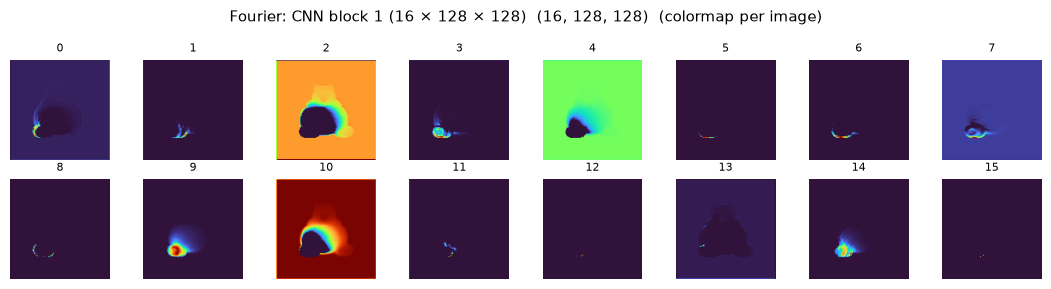

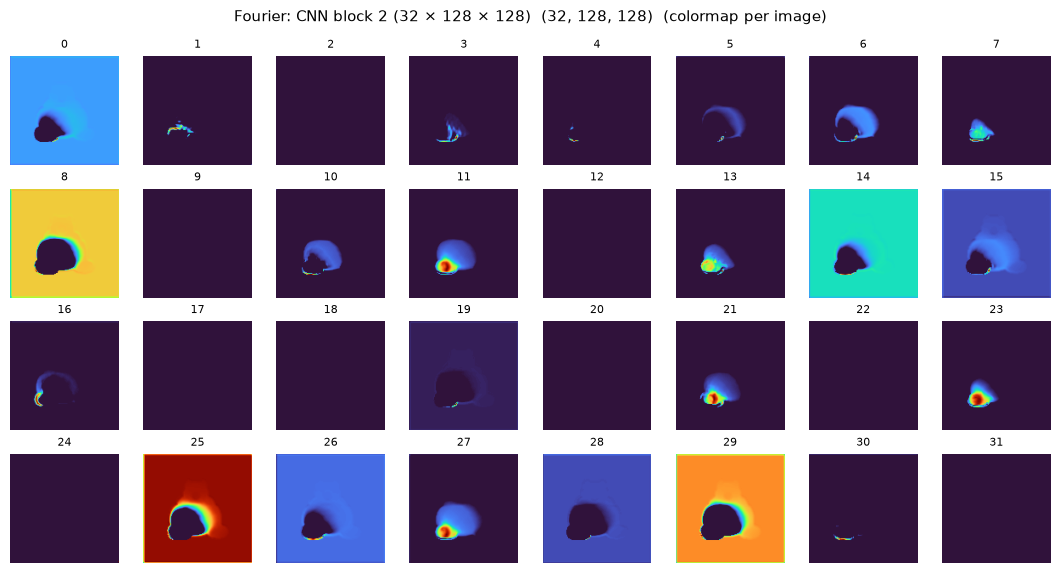

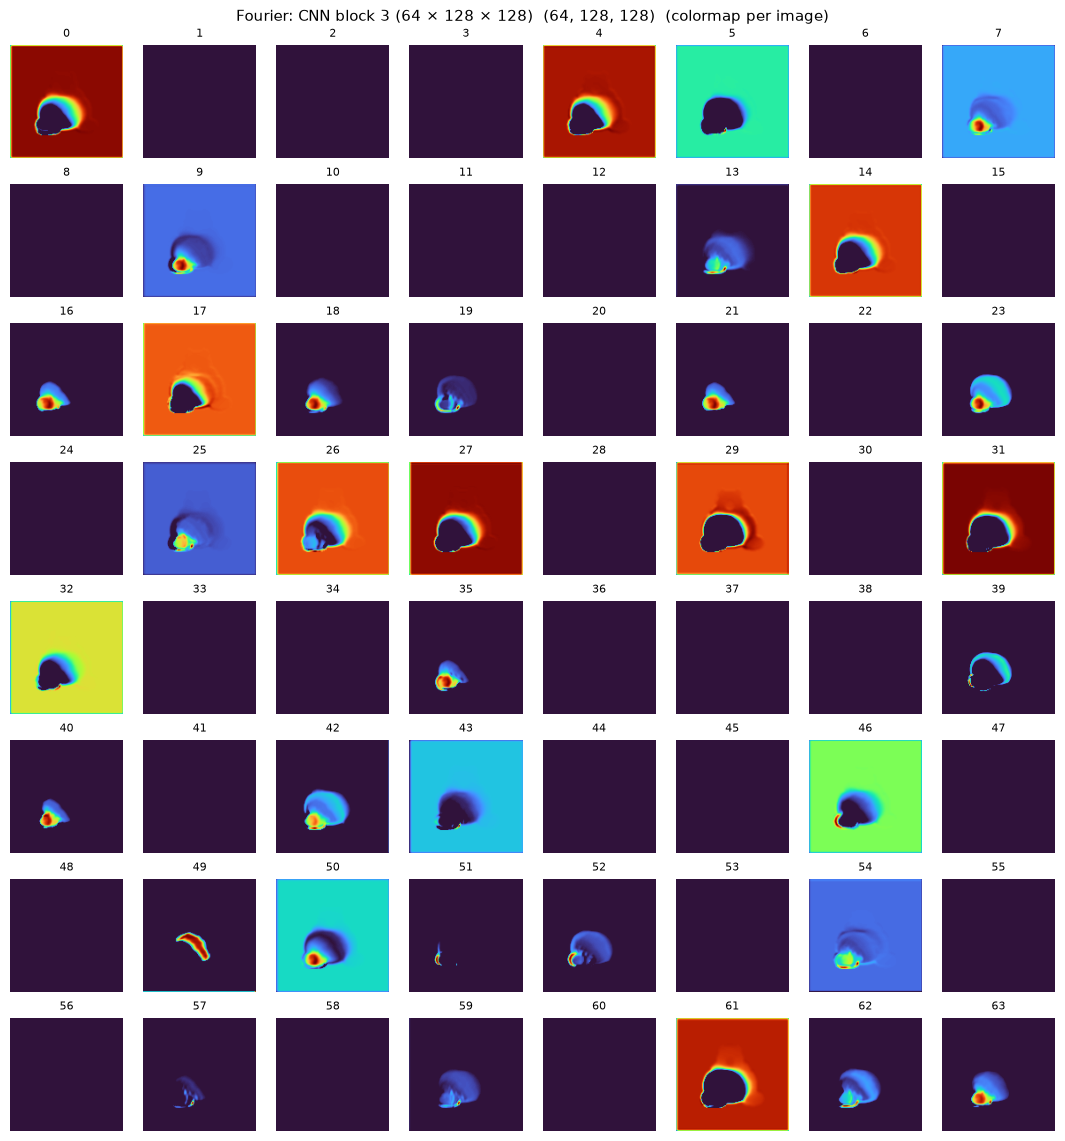

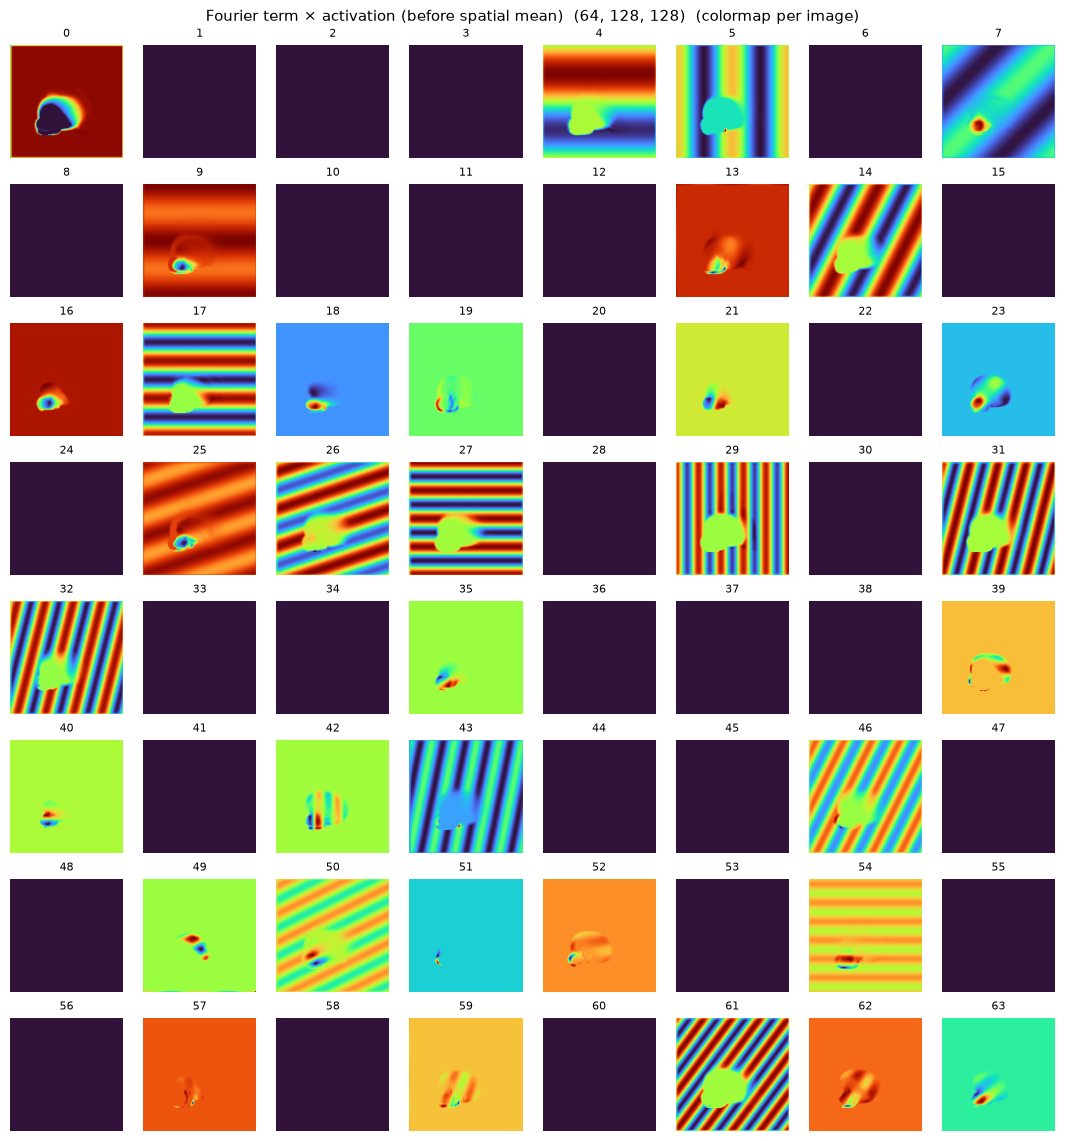

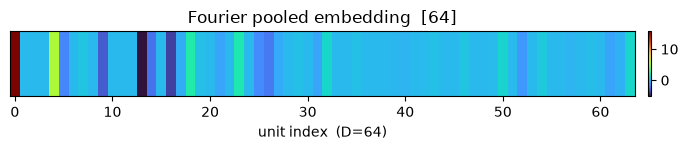

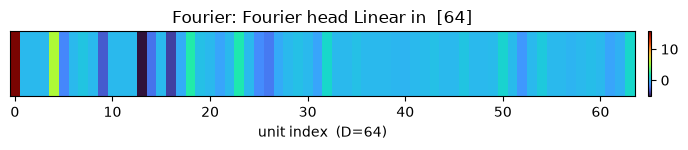

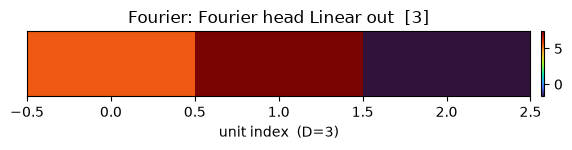

Fourier: predicted vs target particle coordinates
  predicted xyz: [ 5.59868813  7.40354919 -1.72384787]
  target xyz:    [ 5.85024147  6.24563289 -1.62498865]
  error xyz:     [-0.25155334  1.1579163  -0.09885921]


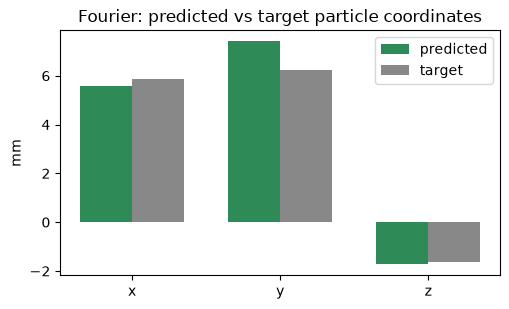

Average pooling (GAP)


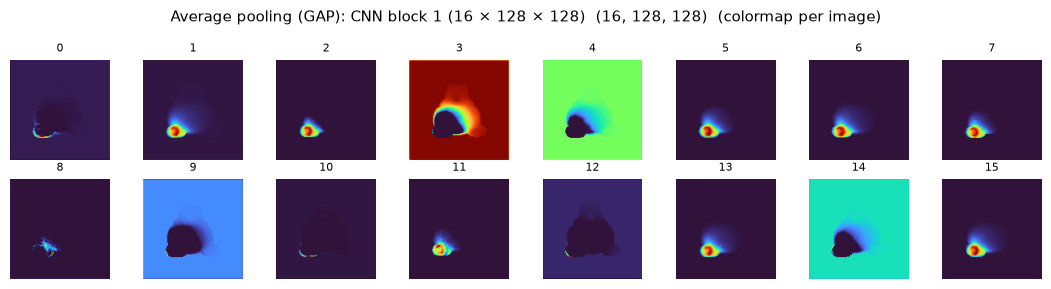

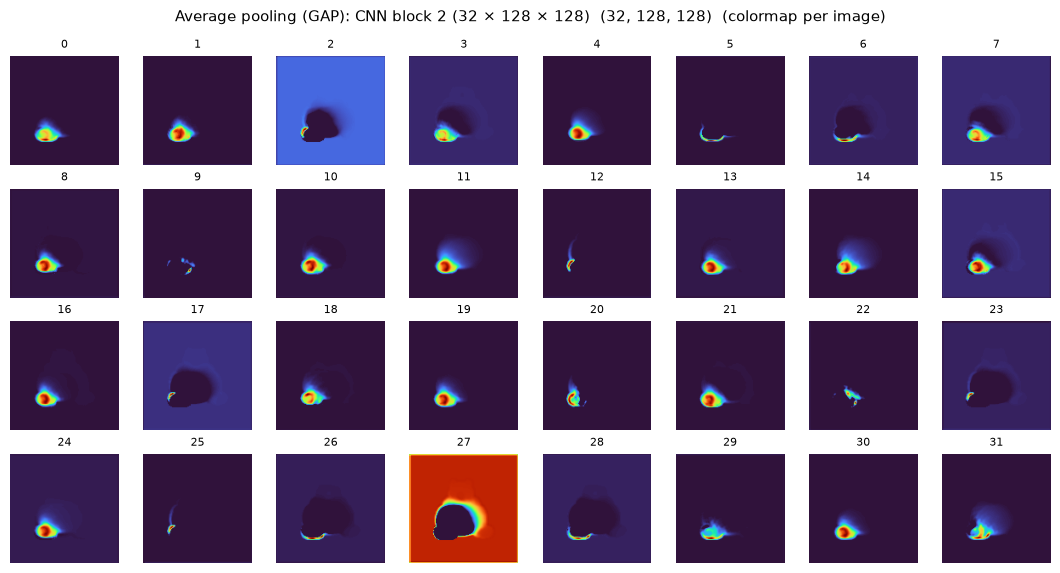

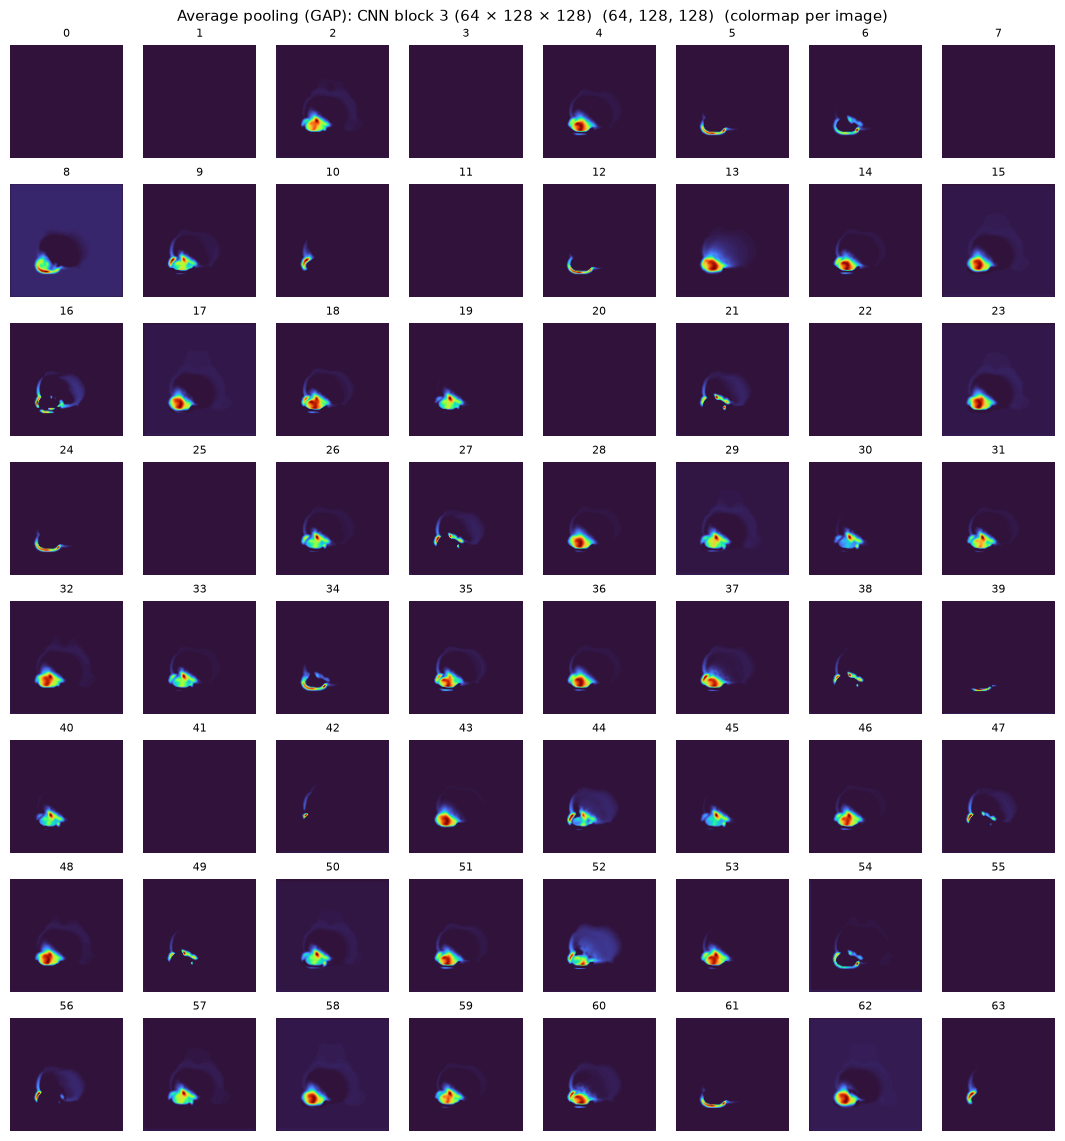

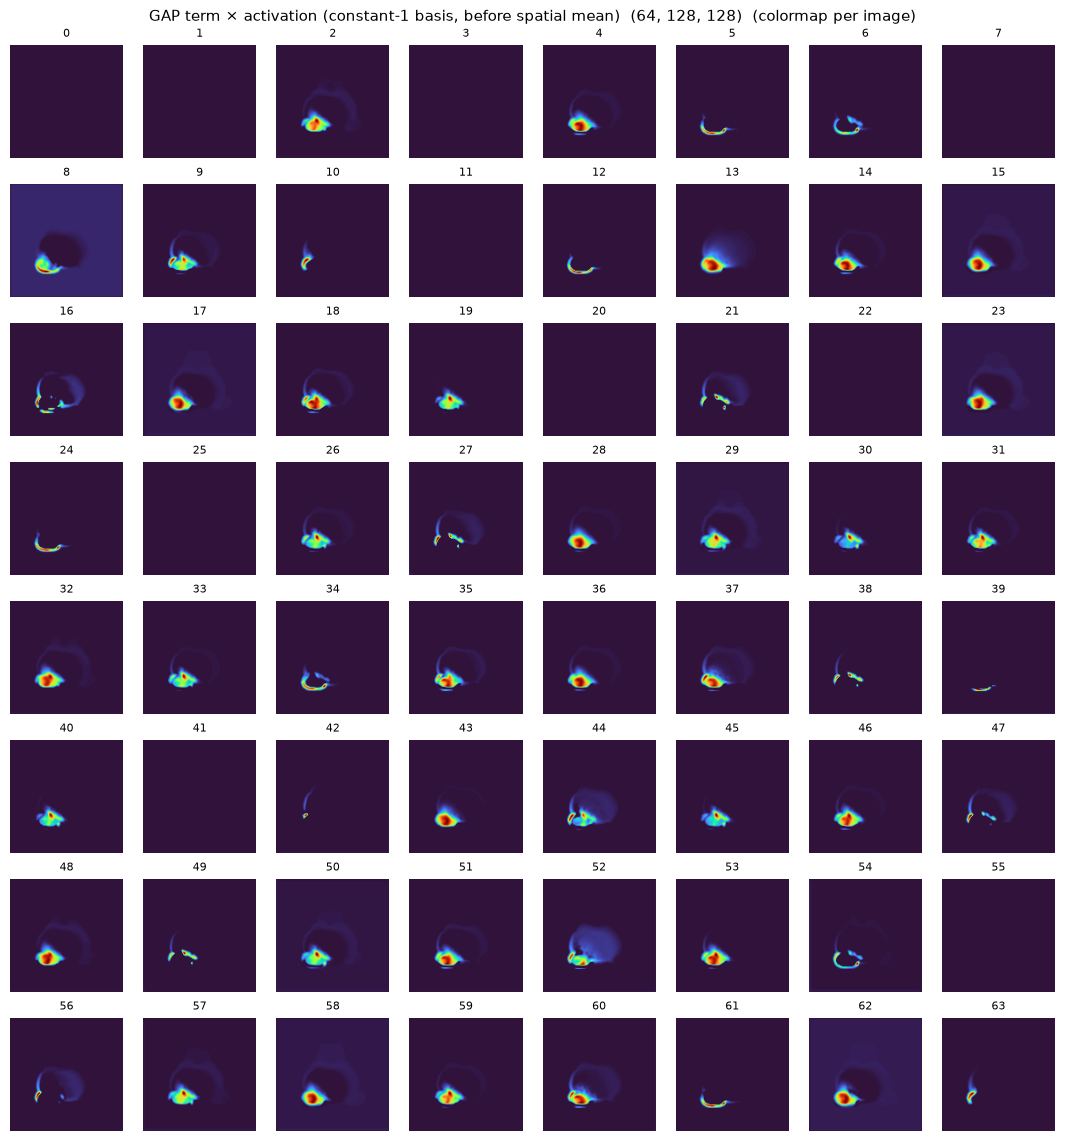

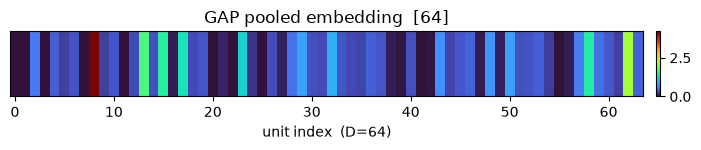

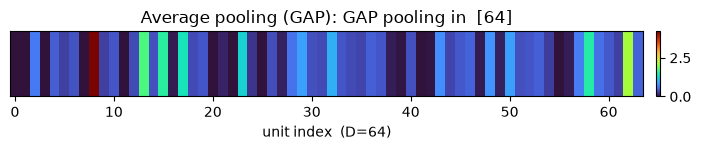

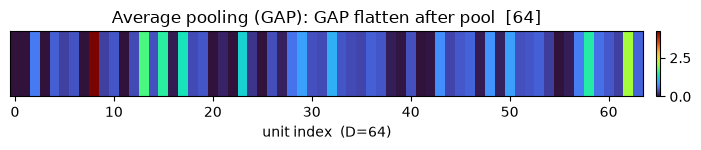

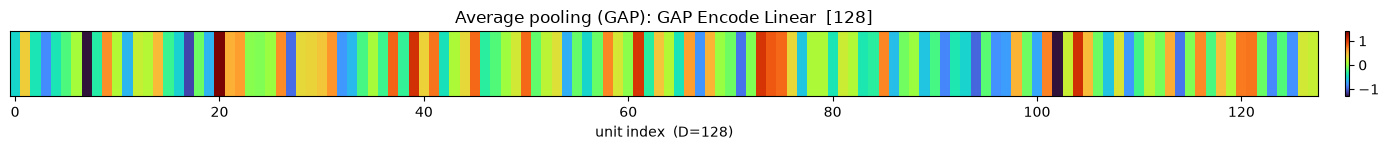

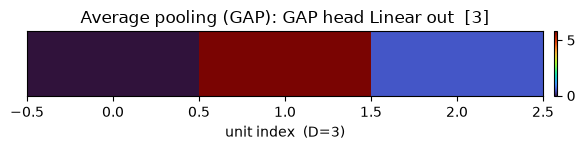

GAP: predicted vs target particle coordinates
  predicted xyz: [-0.08256592  5.79089642  0.48375043]
  target xyz:    [ 5.85024147  6.24563289 -1.62498865]
  error xyz:     [-5.93280738 -0.45473648  2.10873908]


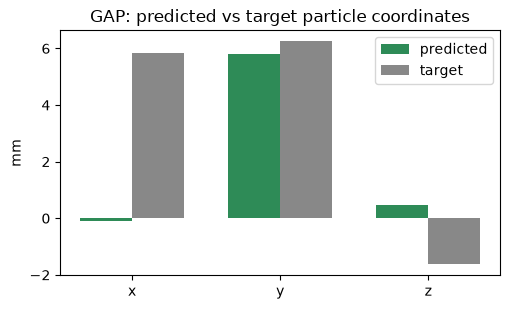

Flatten


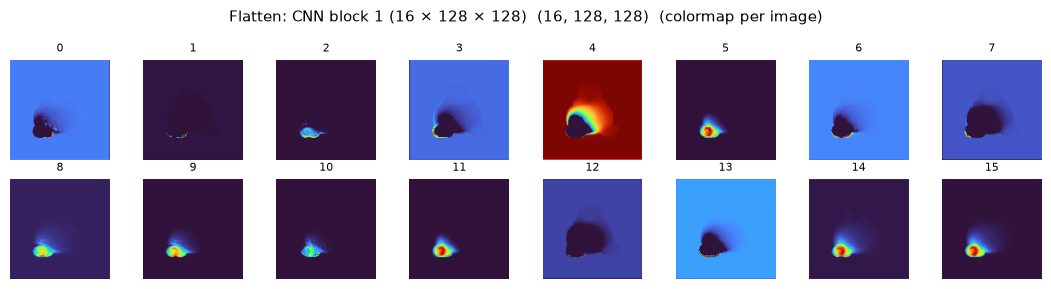

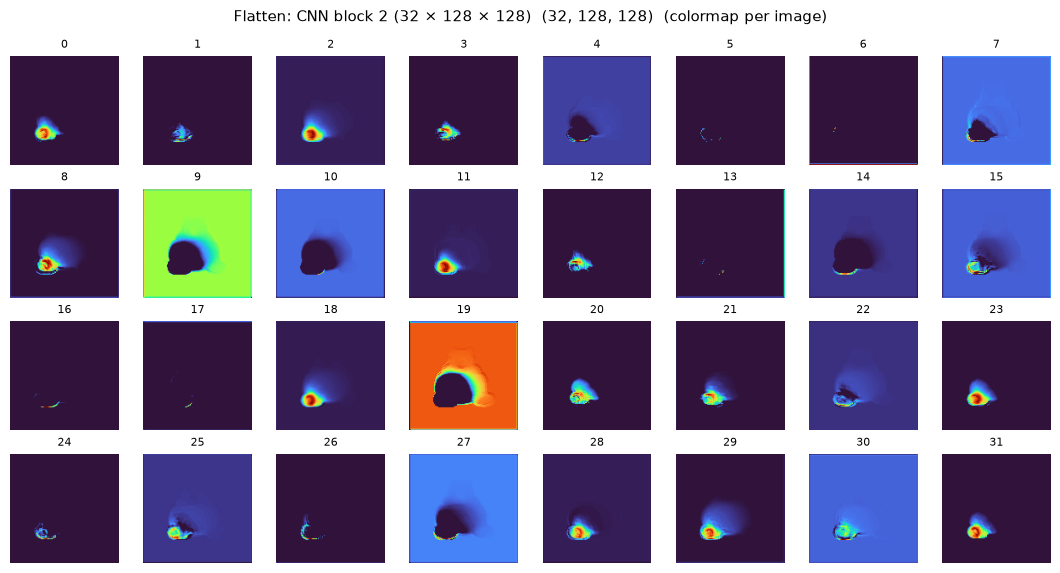

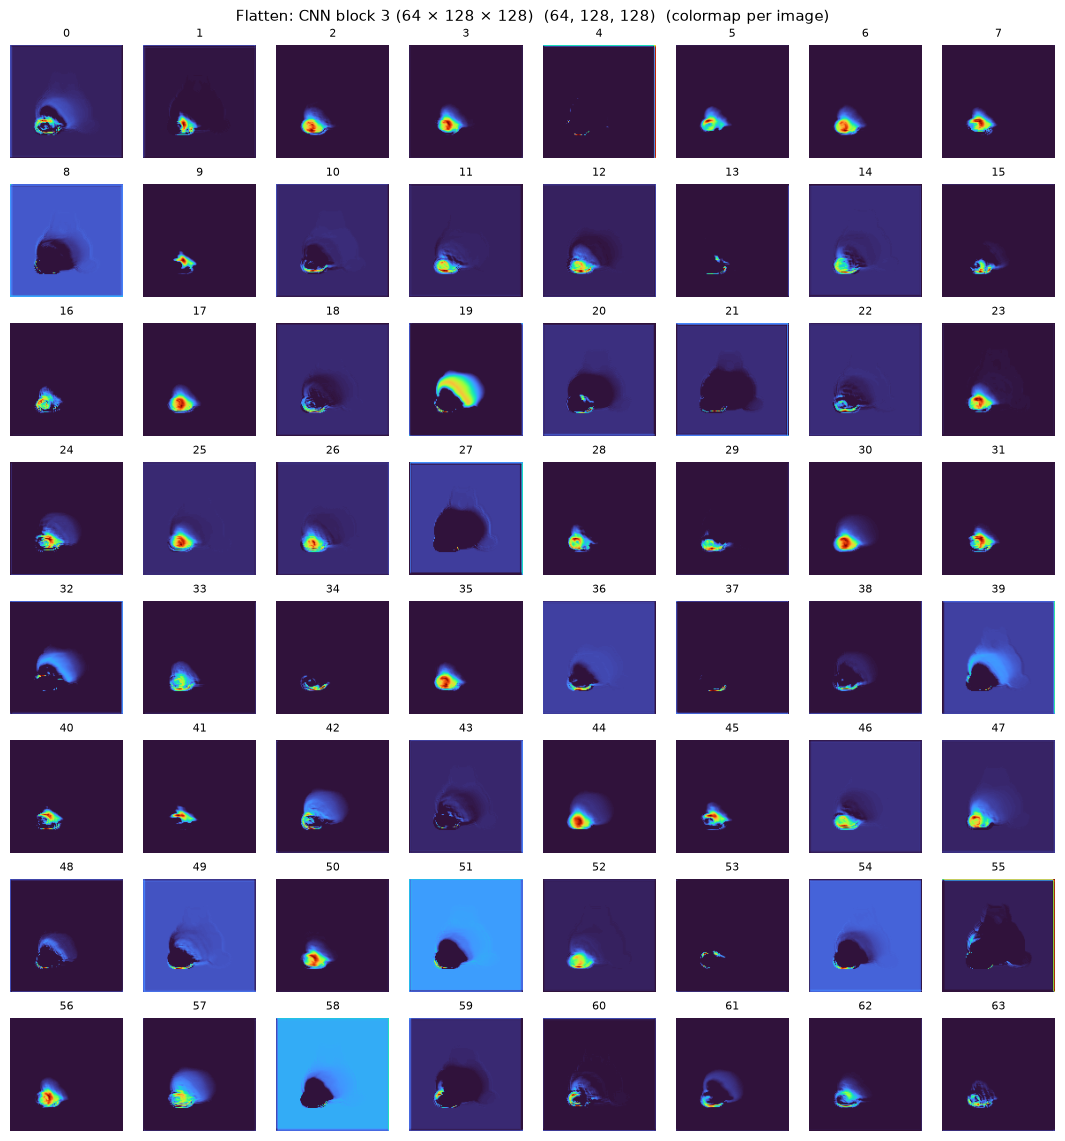

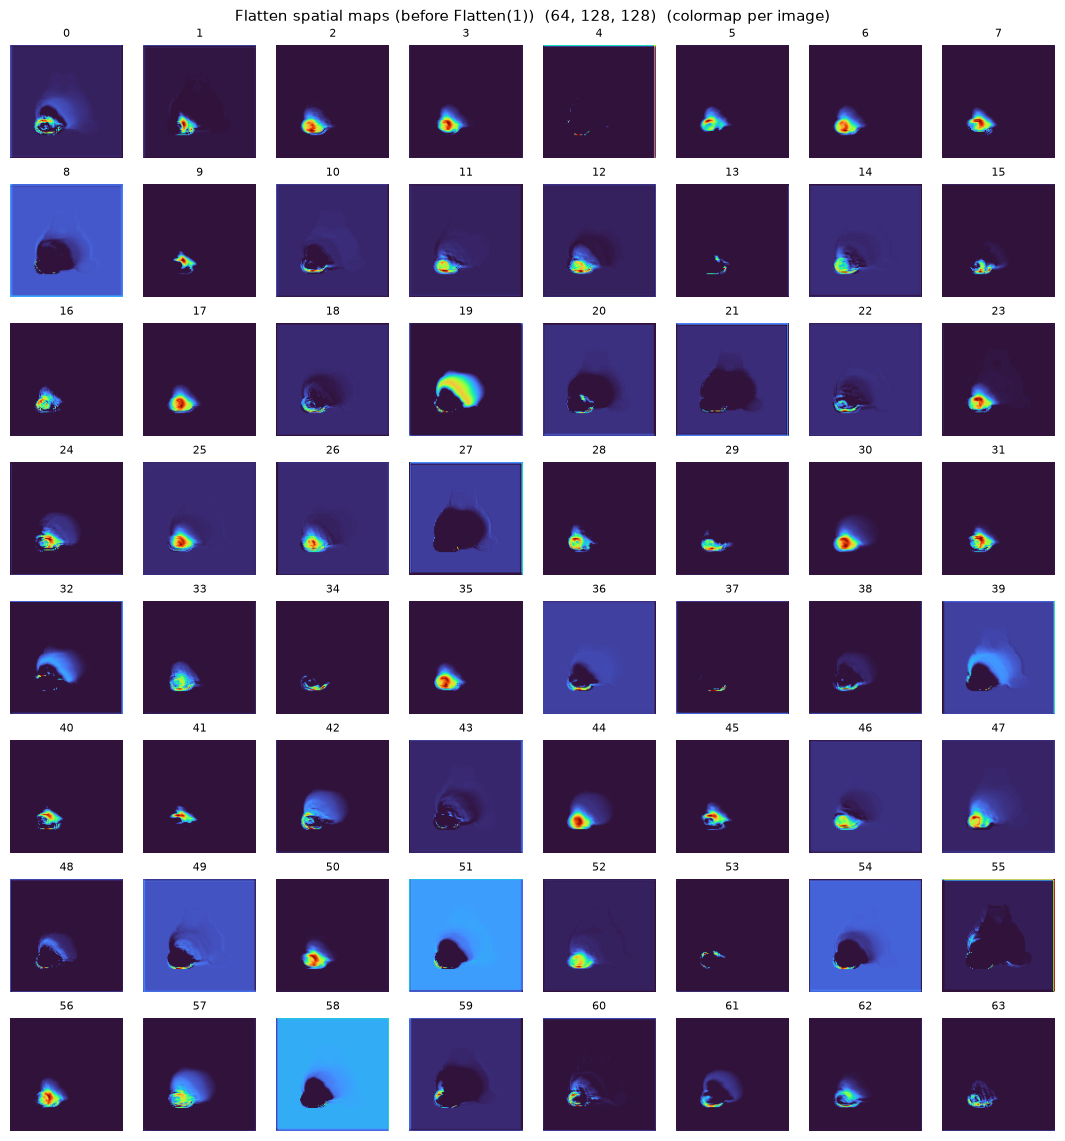

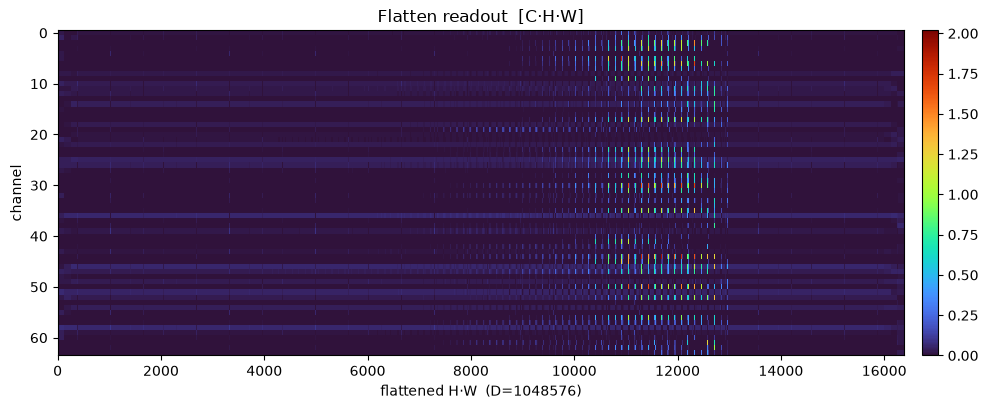

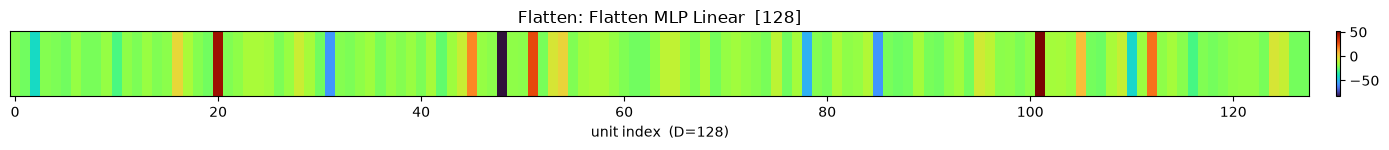

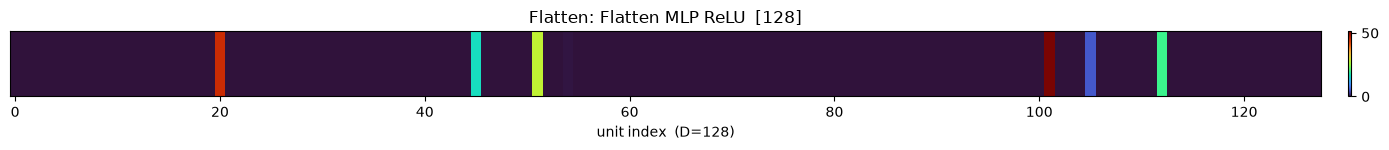

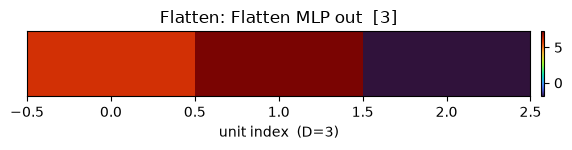

Flatten: predicted vs target particle coordinates
  predicted xyz: [ 6.09690237  7.25830555 -1.918697  ]
  target xyz:    [ 5.85024147  6.24563289 -1.62498865]
  error xyz:     [ 0.2466609   1.01267266 -0.29370835]


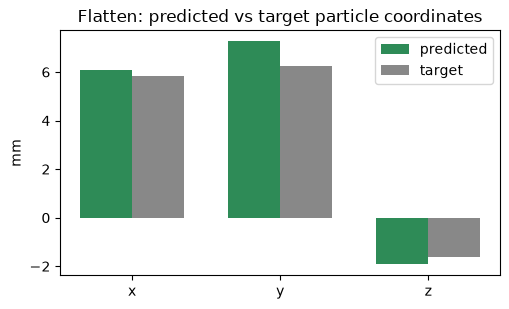

In [98]:
# Same bundle as the POV-Ray figure. Then the same block sequence for GAP.
# GAP “term × activation” uses a constant-1 basis (the maps that are spatially averaged).
# Pooled-arch CNN maps / xyz come from final_state_by_arch["pooled"] when present.
show_bundle_inspections(bundle)

In [99]:
result = export_m8_network_scene(
    sample_index=SAMPLE_INDEX,
    camera_angle_deg=CAMERA_ANGLE_DEG,
    output_pov=OUTPUT_POV,
    manifest_path=MANIFEST_PATH,
    data_root=DATA_ROOT,
    repo_root_path=ROOT,
    render=RENDER,
    setup=setup,
    activations=bundle,
    checkpoint_path=CHECKPOINT_PATH,
    illustration_yaw_deg=ILLUSTRATION_YAW_DEG,
    illustration_fov_deg=ILLUSTRATION_FOV_DEG,
    illustration_distance_scale=ILLUSTRATION_DISTANCE_SCALE,
    illustration_zscore_clip=ILLUSTRATION_ZSCORE_CLIP,
    slice_colormap=SLICE_COLORMAP,
    slice_colormap_clip=SLICE_COLORMAP_CLIP,
    caption_positions=CAPTION_POSITIONS,
    caption_colors=CAPTION_COLORS,
    input_stack_center=INPUT_STACK_CENTER,
    input_stack_scale=INPUT_STACK_SCALE,
    fourier_pane_yaw_deg=FOURIER_PANE_YAW_DEG,
    fourier_group_offset=FOURIER_GROUP_OFFSET,
    cnn_fourier_front=CNN_FOURIER_FRONT,
    fourier_embed_offset=FOURIER_EMBED_OFFSET,
    fourier_embed_scale=FOURIER_EMBED_SCALE,
    gap_embed_yaw_deg=GAP_EMBED_YAW_DEG,
    gap_embed_scale=GAP_EMBED_SCALE,
    gap_embed_shift=GAP_EMBED_SHIFT,
)
for key, path in result.items():
    print(f"{key}: {repo_relative_path(path)}")

pov: outputs/pov/m8_network_scene.pov
png_plain: outputs/renders/m8_network_scene_plain.png
png: outputs/renders/m8_network_scene.png


povray: cannot open the user configuration file ~/.povray/3.7/povray.conf: No such file or directory
Persistence of Vision(tm) Ray Tracer Version 3.7.0.10.unofficial (clang++ 21.0.0
 @ aarch64-apple-darwin25.6.0)
This is an unofficial version compiled by:
 Homebrew
 The POV-Ray Team is not responsible for supporting this version.

POV-Ray is based on DKBTrace 2.12 by David K. Buck & Aaron A. Collins
Copyright 1991-2013 Persistence of Vision Raytracer Pty. Ltd.

Primary POV-Ray 3.7 Architects/Developers: (Alphabetically)
  Chris Cason         Thorsten Froehlich  Christoph Lipka   

With Assistance From: (Alphabetically)
  Ton van den Broek   Nicolas Calimet     Jerome Grimbert     James Holsenback  
  Christoph Hormann   Nathan Kopp         Juha Nieminen     

Past Contributors: (Alphabetically)
  Steve Anger         Eric Barish         Dieter Bayer        David K. Buck     
  Nicolas Calimet     Chris Cason         Aaron A. Collins    Chris Dailey      
  Steve Demlow        Andreas Di

In [100]:
plain = ROOT / "outputs" / "renders" / "m8_network_scene_plain.png"
png = ROOT / "outputs" / "renders" / "m8_network_scene.png"
if not plain.is_file():
    raise FileNotFoundError(
        f"Missing {repo_relative_path(plain)}; run the previous cell with RENDER=True first."
    )
overlay_network_captions(
    png, source=plain, positions=CAPTION_POSITIONS, colors=CAPTION_COLORS
)
print(f"png: {repo_relative_path(png)}")
print(f"png_plain: {repo_relative_path(plain)}")

png: outputs/renders/m8_network_scene.png
png_plain: outputs/renders/m8_network_scene_plain.png
